# f_N vs N: old settings vs new settings

Same 20 N values (100-10,000) from `production_intermediate.yaml`, run
twice under the rolling-window estimator with different parameters, to
check whether extending the burn-in wait / averaging over more windows
/ using more realizations per N smooths out the point-to-point wiggle
seen in the original plot.

- **Old settings:** W_multiplier=5, M=10, c_selfscale=5, min_samples=20
  -> `frozen_fraction_production_intermediate_20260913T064716Z`
- **New settings:** W_multiplier=10, M=20, c_selfscale=10, min_samples=40
  -> `frozen_fraction_production_intermediate_20260913T084452Z`

Exploratory, tied to these two specific runs -- no fitting, no
interpretation of which is "correct".

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

OLD_DIR = Path('../../data/raw/frozen_fraction_production_intermediate_20260913T064716Z')
NEW_DIR = Path('../../data/raw/frozen_fraction_production_intermediate_20260913T084452Z')

def load(run_dir):
    with open(run_dir / 'summary.json') as f:
        summary = sorted(json.load(f), key=lambda row: row['L'])
    N = np.array([row['L'] for row in summary], dtype=float)
    f_N = np.array([row['frozen_fraction_mean'] for row in summary])
    se = np.array([row['frozen_fraction_se'] for row in summary])
    n_samples = np.array([row['n_samples'] for row in summary])
    return N, f_N, se, n_samples

N_old, f_old, se_old, n_old = load(OLD_DIR)
N_new, f_new, se_new, n_new = load(NEW_DIR)

assert np.array_equal(N_old, N_new), 'N grids differ between the two runs'

print(f"{'N':>7} {'f_N (old)':>12} {'f_N (new)':>12} {'diff':>9} {'n (old)':>8} {'n (new)':>8}")
for i in range(len(N_old)):
    print(f'{int(N_old[i]):7d} {f_old[i]:12.4f} {f_new[i]:12.4f} {f_new[i]-f_old[i]:+9.4f} {n_old[i]:8.0f} {n_new[i]:8.0f}')

      N    f_N (old)    f_N (new)      diff  n (old)  n (new)
    100       0.3538       0.3506   -0.0032     1340     1420
    621       0.3602       0.3570   -0.0032      220      240
   1142       0.3656       0.3623   -0.0033      120      140
   1663       0.3624       0.3596   -0.0028       80       80
   2184       0.3628       0.3601   -0.0028       60       60
   2705       0.3646       0.3618   -0.0028       60       60
   3226       0.3583       0.3555   -0.0028       60       60
   3747       0.3671       0.3669   -0.0002       20       40
   4268       0.3638       0.3609   -0.0029       60       60
   4789       0.3623       0.3646   +0.0022       20       40
   5311       0.3656       0.3616   -0.0040       20       40
   5832       0.3643       0.3631   -0.0012       20       40
   6353       0.3605       0.3574   -0.0031       40       40
   6874       0.3620       0.3579   -0.0041       20       40
   7395       0.3682       0.3627   -0.0055       20       40
   7916 

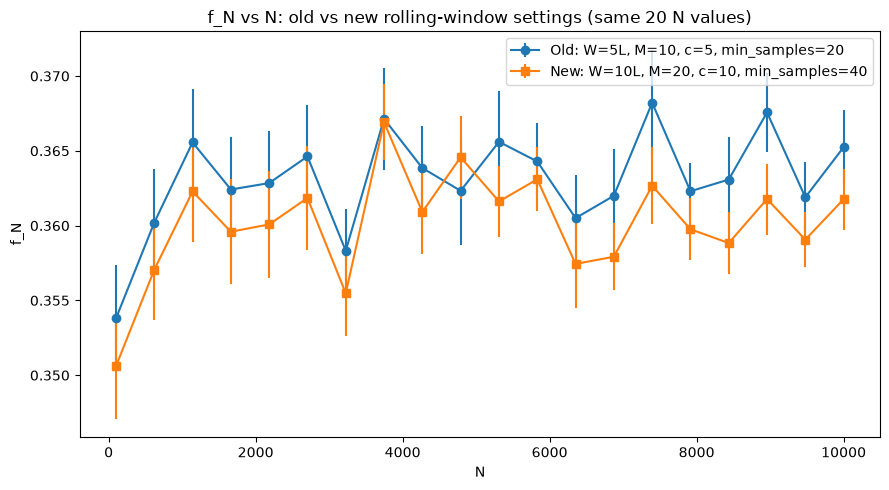

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(N_old, f_old, yerr=se_old, marker='o', linestyle='-', color='C0',
            label='Old: W=5L, M=10, c=5, min_samples=20')
ax.errorbar(N_new, f_new, yerr=se_new, marker='s', linestyle='-', color='C1',
            label='New: W=10L, M=20, c=10, min_samples=40')

ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N: old vs new rolling-window settings (same 20 N values)')
ax.legend()
fig.tight_layout()
plt.show()

## Quantifying "wiggle": residual from a smooth trend

Not a physics fit -- just a diagnostic. Fits a simple smooth reference
(local weighted average via a low-order polynomial in log N) to each
series and looks at the leftover point-to-point scatter around it, to
compare the two settings on equal footing rather than relying on
eyeballing the plot above.

Weighted RMS residual from a degree-2 log(N) polynomial:
  old settings: 0.00236
  new settings: 0.00244
  ratio (new/old): 1.032  (values below 1 => new settings less wiggly by this measure)


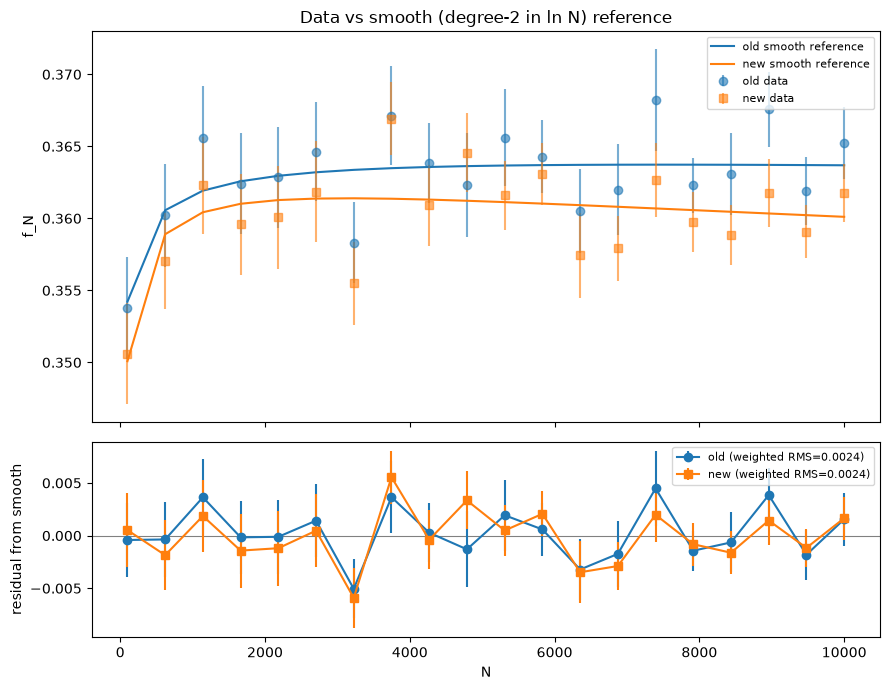

In [3]:
def residual_scatter(N, f, se, degree=2):
    x = np.log(N)
    weights = 1.0 / se**2
    coeffs = np.polyfit(x, f, degree, w=np.sqrt(weights))
    smooth = np.polyval(coeffs, x)
    resid = f - smooth
    weighted_rms = np.sqrt(np.sum(weights * resid**2) / np.sum(weights))
    return smooth, resid, weighted_rms

smooth_old, resid_old, rms_old = residual_scatter(N_old, f_old, se_old)
smooth_new, resid_new, rms_new = residual_scatter(N_new, f_new, se_new)

print(f'Weighted RMS residual from a degree-2 log(N) polynomial:')
print(f'  old settings: {rms_old:.5f}')
print(f'  new settings: {rms_new:.5f}')
print(f'  ratio (new/old): {rms_new/rms_old:.3f}  (values below 1 => new settings less wiggly by this measure)')

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1])

ax = axes[0]
ax.errorbar(N_old, f_old, yerr=se_old, marker='o', linestyle='none', color='C0', alpha=0.6, label='old data')
ax.plot(N_old, smooth_old, color='C0', label='old smooth reference')
ax.errorbar(N_new, f_new, yerr=se_new, marker='s', linestyle='none', color='C1', alpha=0.6, label='new data')
ax.plot(N_new, smooth_new, color='C1', label='new smooth reference')
ax.set_ylabel('f_N')
ax.legend(fontsize=8)
ax.set_title('Data vs smooth (degree-2 in ln N) reference')

ax = axes[1]
ax.axhline(0, color='gray', linewidth=0.8)
ax.errorbar(N_old, resid_old, yerr=se_old, marker='o', color='C0', label=f'old (weighted RMS={rms_old:.4f})')
ax.errorbar(N_new, resid_new, yerr=se_new, marker='s', color='C1', label=f'new (weighted RMS={rms_new:.4f})')
ax.set_xlabel('N')
ax.set_ylabel('residual from smooth')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()